# Phase9 Visualization (Concept-first, Cleaner)
Figure text is English only.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
sns.set_theme(style='whitegrid', context='notebook')

DATA = Path('/workspace/jy1559/FMoE/experiments/run/fmoe_n3/docs/data/phase8_9')
DIAG_COLS = [
    'diag_n_eff','diag_cv_usage','diag_top1_max_frac','diag_entropy_mean',
    'diag_route_jitter_adjacent','diag_route_consistency_knn_score',
    'diag_route_consistency_group_knn_score','diag_route_consistency_intra_group_knn_mean_score',
    'diag_family_top_expert_mean_share'
]
DIAG_ALIAS = {
    'diag_n_eff':'n_eff',
    'diag_cv_usage':'cv_usage',
    'diag_top1_max_frac':'top1_max',
    'diag_entropy_mean':'entropy',
    'diag_route_jitter_adjacent':'jitter_adj',
    'diag_route_consistency_knn_score':'knn_cons',
    'diag_route_consistency_group_knn_score':'group_knn_cons',
    'diag_route_consistency_intra_group_knn_mean_score':'intra_knn_cons',
    'diag_family_top_expert_mean_share':'family_top_share',
}

def short_label(s: str, max_len: int = 28) -> str:
    if pd.isna(s):
        return ''
    x = str(s)
    repl = {
        'MIXED_':'M', 'ALL_W':'W', 'BIAS_':'B_', 'SRC_':'S_', 'TK_':'T_',
        'A_HIDDEN_B_D_FEATURE':'AHBDF', 'ABC_FEATURE':'ABCF', 'ALL_BOTH':'ALLB',
        'GROUP_FEAT':'GF', 'FEATURE_ALIGN':'FALIGN', 'ROUTE_SMOOTHNESS':'RSM',
    }
    for k,v in repl.items():
        x = x.replace(k,v)
    return x if len(x) <= max_len else x[:max_len-1] + '...'

def tight_lim(vals, ratio=0.08, min_pad=0.00012):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (0.0, 1.0)
    vmin = vals.min(); vmax = vals.max()
    span = max(vmax - vmin, min_pad)
    pad = max(span * ratio, min_pad)
    return (vmin - pad, vmax + pad*2.0)

def annotate_barh(ax, fmt='{:.4f}'):
    xmin, xmax = ax.get_xlim()
    off = (xmax - xmin) * 0.009
    for p in ax.patches:
        w = p.get_width()
        y = p.get_y() + p.get_height()/2
        ax.text(w + off, y, fmt.format(w), va='center', ha='left', fontsize=7.5)

def ordered_barh(ax, df, value_col, label_col, group_col=None, title='', xlabel='', show_legend=True, add_ref=True):
    d = df.copy().reset_index(drop=True)
    y = np.arange(len(d))
    if group_col is not None and group_col in d.columns:
        groups = d[group_col].astype(str).fillna('NA')
        uniq = list(dict.fromkeys(groups.tolist()))
        pal = sns.color_palette('tab20', n_colors=max(3, len(uniq)))
        cmap = {g: pal[i % len(pal)] for i,g in enumerate(uniq)}
        colors = [cmap[g] for g in groups]
    else:
        colors = ['#4C72B0'] * len(d)
        groups = None
        cmap = {}

    ax.barh(y, d[value_col].values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels([short_label(v, 30) for v in d[label_col].tolist()], fontsize=7.6)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xlim(*tight_lim(d[value_col].values))
    annotate_barh(ax)

    if add_ref:
        m = float(np.nanmean(d[value_col].values))
        ax.axvline(m, color='#222222', lw=0.8, ls='--', alpha=0.45)

    if groups is not None and len(groups) > 0:
        prev = groups.iloc[0]
        for i, g in enumerate(groups.iloc[1:], start=1):
            if g != prev:
                ax.axhline(i-0.5, color='black', lw=0.6, alpha=0.35)
            prev = g

        if show_legend:
            handles = []
            labels = []
            for g in dict.fromkeys(groups.tolist()):
                handles.append(Line2D([0],[0], marker='s', color='none', markerfacecolor=cmap[g], markersize=7))
                labels.append(short_label(g, 14))
            ax.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01,0.5), frameon=True, title=group_col, fontsize=7, title_fontsize=8)

def diag_facet_scatter(df, y_col, hue_col, style_col, title_prefix):
    long = df.melt(
        id_vars=[y_col, hue_col, style_col],
        value_vars=DIAG_COLS,
        var_name='diag_metric',
        value_name='diag_value'
    ).dropna()
    long['diag_metric_short'] = long['diag_metric'].map(DIAG_ALIAS)
    long['hue_label'] = long[hue_col].astype(str).map(lambda s: short_label(s, 12))
    long['style_label'] = long[style_col].astype(str).map(lambda s: short_label(s, 12))

    hue_levels = list(dict.fromkeys(long['hue_label'].tolist()))
    style_levels = list(dict.fromkeys(long['style_label'].tolist()))
    palette = {k: sns.color_palette('tab10', n_colors=max(3, len(hue_levels)))[i % max(3, len(hue_levels))] for i,k in enumerate(hue_levels)}
    marker_bank = ['o','s','^','D','P','X','v','<','>','*','h','8']
    markers = {k: marker_bank[i % len(marker_bank)] for i,k in enumerate(style_levels)}

    g = sns.FacetGrid(long, col='diag_metric_short', col_wrap=3, sharex=False, sharey=True, height=2.7, despine=False)
    g.map_dataframe(
        sns.scatterplot,
        x='diag_value', y=y_col,
        hue='hue_label', style='style_label',
        palette=palette, markers=markers,
        s=14, alpha=0.62, edgecolor='none', legend=False,
    )
    g.set_titles('{col_name}')
    g.set_axis_labels('diag_value', y_col)
    for ax in g.axes.flatten():
        ax.grid(alpha=0.2)

    hue_handles = [Line2D([0],[0], marker='o', color='none', markerfacecolor=palette[k], label=k, markersize=5.8) for k in hue_levels]
    style_handles = [Line2D([0],[0], marker=markers[k], color='#333333', linestyle='', label=k, markersize=5.8) for k in style_levels]

    g.fig.suptitle(title_prefix, y=0.98)
    g.fig.legend(hue_handles, [h.get_label() for h in hue_handles], loc='lower center', bbox_to_anchor=(0.5, 0.055), ncol=min(6, len(hue_handles)), frameon=True, title=hue_col, fontsize=7, title_fontsize=8)
    g.fig.legend(style_handles, [h.get_label() for h in style_handles], loc='lower center', bbox_to_anchor=(0.5, 0.005), ncol=min(6, len(style_handles)), frameon=True, title=style_col, fontsize=7, title_fontsize=8)
    g.fig.subplots_adjust(top=0.90, bottom=0.20, wspace=0.28, hspace=0.34)
    return g

def top_bottom_diag_delta(df, perf_col, title):
    q1 = df[perf_col].quantile(0.25)
    q3 = df[perf_col].quantile(0.75)
    top = df[df[perf_col] >= q3]
    bot = df[df[perf_col] <= q1]
    delta = (top[DIAG_COLS].mean() - bot[DIAG_COLS].mean()).reset_index()
    delta.columns = ['diag_metric','delta']
    delta['diag_metric'] = delta['diag_metric'].map(DIAG_ALIAS)
    delta = delta.sort_values('delta', ascending=False)
    plt.figure(figsize=(8.4,4.8))
    ax = sns.barplot(data=delta, x='diag_metric', y='delta', palette='coolwarm')
    ax.axhline(0, color='black', lw=0.9)
    ax.set_title(title)
    ax.set_xlabel('diag_metric')
    ax.set_ylabel('top-bottom delta')
    plt.xticks(rotation=35, ha='right')
    for i,v in enumerate(delta['delta'].values):
        ax.text(i, v + np.sign(v)*0.0015, f'{v:.3f}', ha='center', va='bottom' if v>=0 else 'top', fontsize=7.5)
    plt.tight_layout()

def group_diag_heatmap(df, group_col, title):
    g = df.groupby(group_col)[DIAG_COLS].mean()
    z = (g - g.mean()) / g.std(ddof=0)
    z = z.rename(columns=DIAG_ALIAS)
    plt.figure(figsize=(10, 3 + 0.4*len(z)))
    sns.heatmap(z, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.3)
    plt.title(title)
    plt.tight_layout()

def diag_corr_heatmap(df, group_col, perf_col, title):
    rows = []
    for g, sub in df.groupby(group_col):
        for c in DIAG_COLS:
            corr = sub[c].corr(sub[perf_col], method='spearman')
            rows.append({'group':str(g), 'diag_metric':DIAG_ALIAS.get(c,c), 'corr':corr})
    t = pd.DataFrame(rows).pivot(index='group', columns='diag_metric', values='corr')
    plt.figure(figsize=(10, 3 + 0.42*len(t)))
    sns.heatmap(t, cmap='vlag', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.3)
    plt.title(title)
    plt.tight_layout()

def diag_corr_summary(df, perf_col):
    rows = []
    for c in DIAG_COLS:
        sub = df[[c, perf_col]].dropna()
        if len(sub) < 3:
            s_corr = np.nan
            p_corr = np.nan
        else:
            s_corr = sub[c].corr(sub[perf_col], method='spearman')
            p_corr = sub[c].corr(sub[perf_col], method='pearson')
        rows.append({
            'diag_metric': DIAG_ALIAS.get(c, c),
            'spearman': s_corr,
            'pearson': p_corr,
            'abs_spearman': np.nan if pd.isna(s_corr) else abs(s_corr),
        })
    out = pd.DataFrame(rows).sort_values('abs_spearman', ascending=False).reset_index(drop=True)
    return out[['diag_metric', 'spearman', 'pearson']]

def diag_quantile_profile(df, perf_col, title):
    n = len(DIAG_COLS)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.2*rows), sharey=False)
    axes = np.array(axes).reshape(-1)
    for i, c in enumerate(DIAG_COLS):
        ax = axes[i]
        d = df[[c, perf_col]].dropna().copy()
        if d[c].nunique() < 4:
            ax.axis('off')
            continue
        d['qbin'] = pd.qcut(d[c], q=5, duplicates='drop')
        q = d.groupby('qbin', observed=False)[perf_col].mean().reset_index()
        q = q.dropna().reset_index(drop=True)
        if q.empty:
            ax.axis('off')
            continue
        q['qbin_idx'] = np.arange(1, len(q) + 1)
        sns.lineplot(data=q, x='qbin_idx', y=perf_col, marker='o', color='#4C72B0', ax=ax)
        ax.set_title(DIAG_ALIAS.get(c,c))
        ax.set_xlabel('diag quantile')
        ax.set_ylabel(perf_col)
        ax.set_xticks(q['qbin_idx'].tolist())
        ax.set_ylim(*tight_lim(q[perf_col].values, ratio=0.20, min_pad=0.00008))
        for _, r in q.iterrows():
            ax.text(r['qbin_idx'], r[perf_col] + 0.00005, f"{r[perf_col]:.4f}", ha='center', va='bottom', fontsize=6.8)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle(title, y=1.01)
    plt.tight_layout()

def pca_family_scatter(pts, title, hue_col, style_col='family', cmap='viridis', categorical_hue=False):
    fig, ax = plt.subplots(figsize=(7.8,6.0))
    if categorical_hue:
        sns.scatterplot(data=pts, x='pc1', y='pc2', hue=hue_col, style=style_col, s=24, alpha=0.78, ax=ax)
        leg = ax.legend(loc='center left', bbox_to_anchor=(1.02,0.5), frameon=True, fontsize=7, title_fontsize=8)
    else:
        sns.scatterplot(data=pts, x='pc1', y='pc2', hue=hue_col, style=style_col, s=24, alpha=0.78, palette=cmap, ax=ax)
        leg = ax.legend(loc='center left', bbox_to_anchor=(1.02,0.5), frameon=True, fontsize=7, title_fontsize=8)
    ax.axhline(0, color='#999999', lw=0.8, ls='--', alpha=0.55)
    ax.axvline(0, color='#999999', lw=0.8, ls='--', alpha=0.55)
    ax.set_title(title)
    return fig, ax

p9 = pd.read_csv(DATA / 'phase9_main.csv')
p92 = pd.read_csv(DATA / 'phase9_2_main.csv')
p92p = pd.read_csv(DATA / 'phase9_2_pending.csv')
pca = pd.read_csv(DATA / 'family_expert_pca_points.csv')
p9_pca = pca[pca.phase_tag.isin(['phase9','phase9_2'])].copy()

p9['ts'] = pd.to_datetime(p9['timestamp'], errors='coerce')
print('한글 설명: Phase9는 concept 축 중심으로, 내부 비교는 실험 순서, 최종 비교는 내림차순으로 표시합니다.')
print('9_2는 진행률 위주로 짧게 유지합니다.')


한글 설명: Phase9는 concept 축 중심으로, 내부 비교는 실험 순서, 최종 비교는 내림차순으로 표시합니다.
9_2는 진행률 위주로 짧게 유지합니다.


concept 내부 비교(실험 순서): VALID


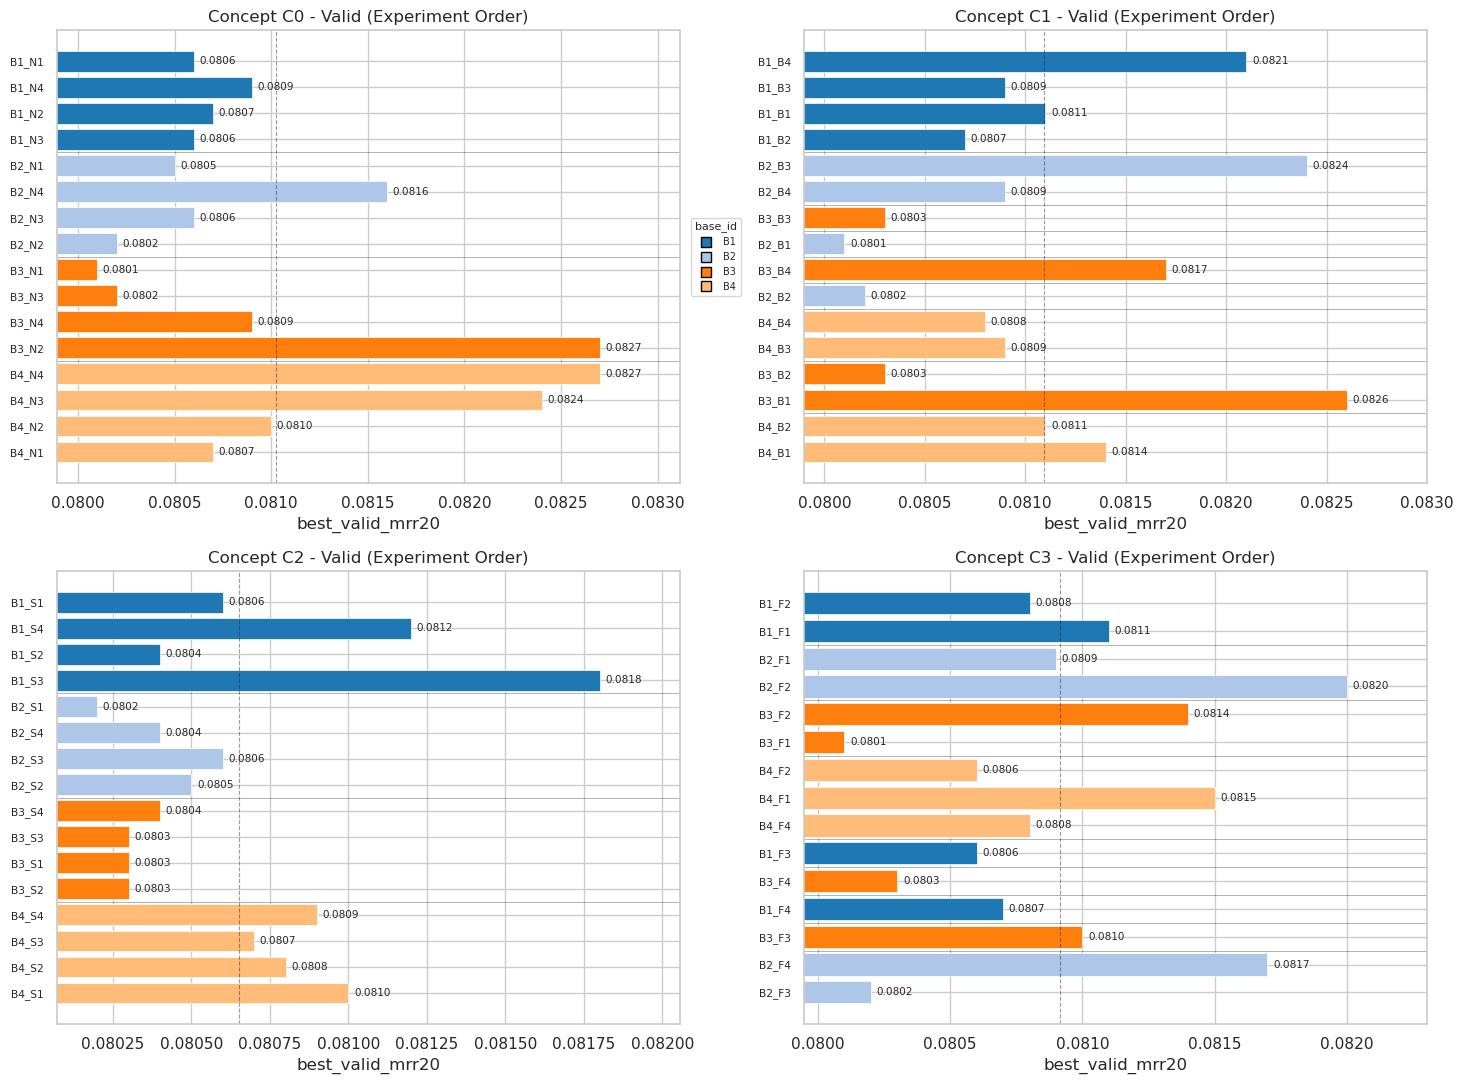

In [2]:
print('concept 내부 비교(실험 순서): VALID')
fig, axes = plt.subplots(2,2, figsize=(14.8,11.0))
for i, (ax, c) in enumerate(zip(axes.flatten(), ['C0','C1','C2','C3'])):
    sub = p9[p9.concept_id==c].copy().sort_values('ts')
    sub['label'] = (sub['base_id'] + '_' + sub['combo_id']).map(short_label)
    ordered_barh(ax, sub, 'best_valid_mrr20', 'label', group_col='base_id', show_legend=(i==0), title=f'Concept {c} - Valid (Experiment Order)', xlabel='best_valid_mrr20')
plt.tight_layout()
plt.show()


concept 내부 비교(실험 순서): TEST


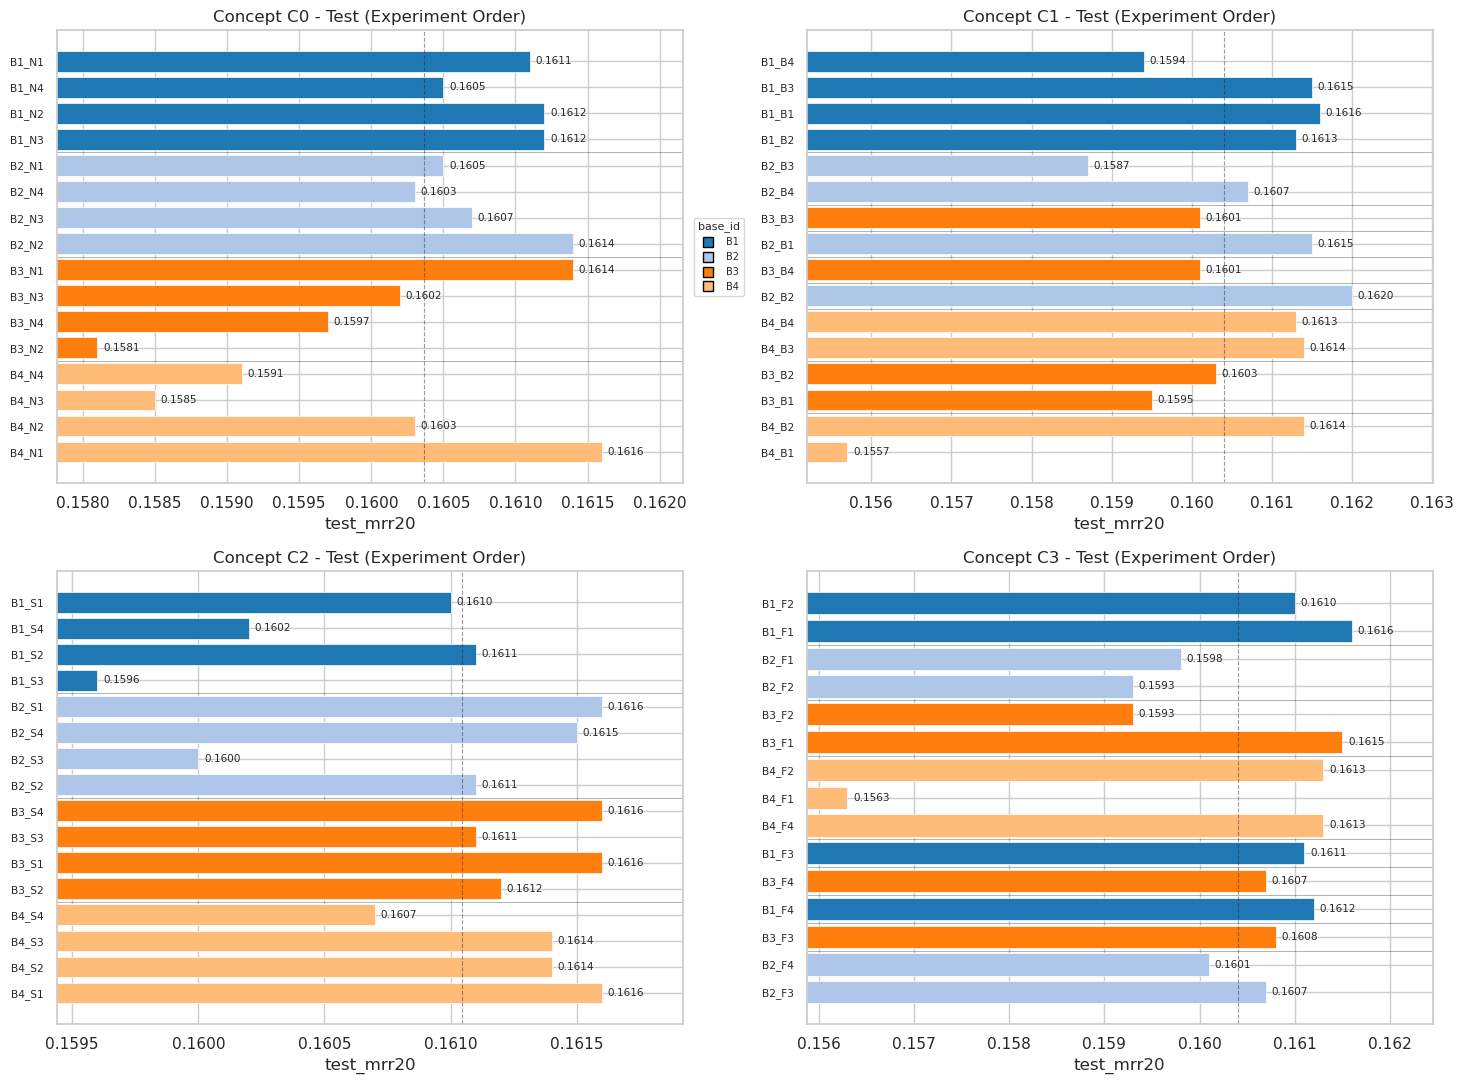

In [3]:
print('concept 내부 비교(실험 순서): TEST')
fig, axes = plt.subplots(2,2, figsize=(14.8,11.0))
for i, (ax, c) in enumerate(zip(axes.flatten(), ['C0','C1','C2','C3'])):
    sub = p9[p9.concept_id==c].copy().sort_values('ts')
    sub['label'] = (sub['base_id'] + '_' + sub['combo_id']).map(short_label)
    ordered_barh(ax, sub, 'test_mrr20', 'label', group_col='base_id', show_legend=(i==0), title=f'Concept {c} - Test (Experiment Order)', xlabel='test_mrr20')
plt.tight_layout()
plt.show()


최종 요약(내림차순): concept별 best


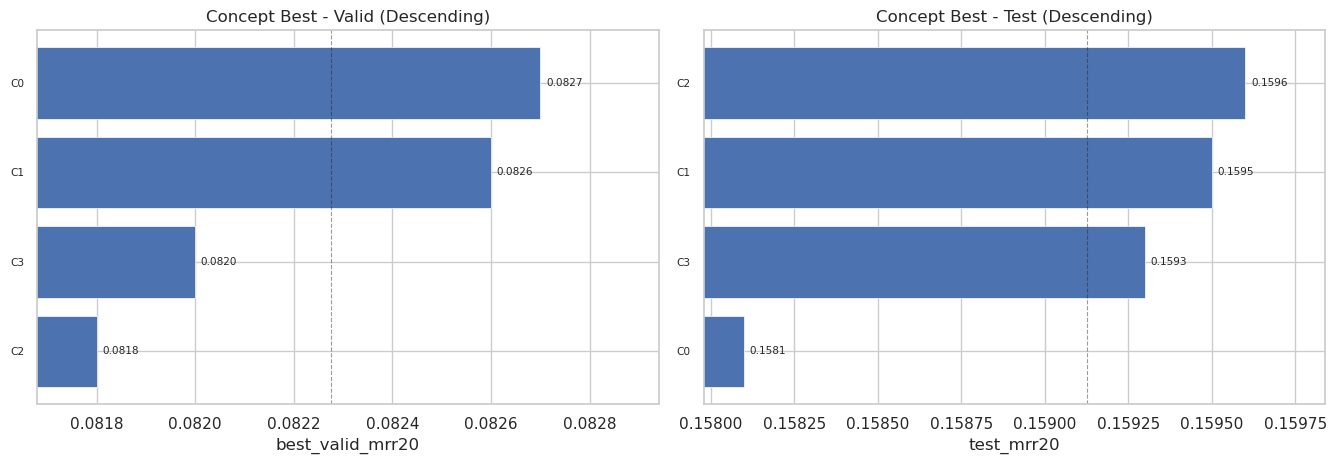

In [4]:
print('최종 요약(내림차순): concept별 best')
best = p9.sort_values(['concept_id','best_valid_mrr20'], ascending=[True,False]).groupby('concept_id', as_index=False).first()
fig, axs = plt.subplots(1,2, figsize=(13.6,4.8))
ordered_barh(axs[0], best.sort_values('best_valid_mrr20', ascending=False), 'best_valid_mrr20', 'concept_id', title='Concept Best - Valid (Descending)', xlabel='best_valid_mrr20')
ordered_barh(axs[1], best.sort_values('test_mrr20', ascending=False), 'test_mrr20', 'concept_id', title='Concept Best - Test (Descending)', xlabel='test_mrr20')
plt.tight_layout()
plt.show()


diag scatter(VALID): color=concept, marker=base


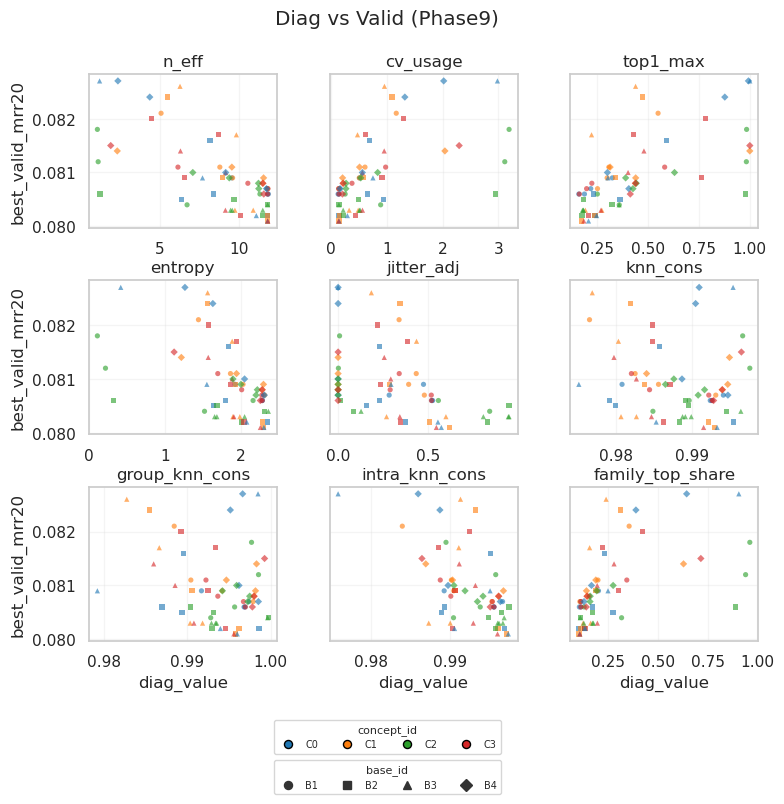

In [5]:
print('diag scatter(VALID): color=concept, marker=base')
_ = diag_facet_scatter(p9, 'best_valid_mrr20', 'concept_id', 'base_id', 'Diag vs Valid (Phase9)')
plt.show()


diag scatter(TEST): color=concept, marker=base


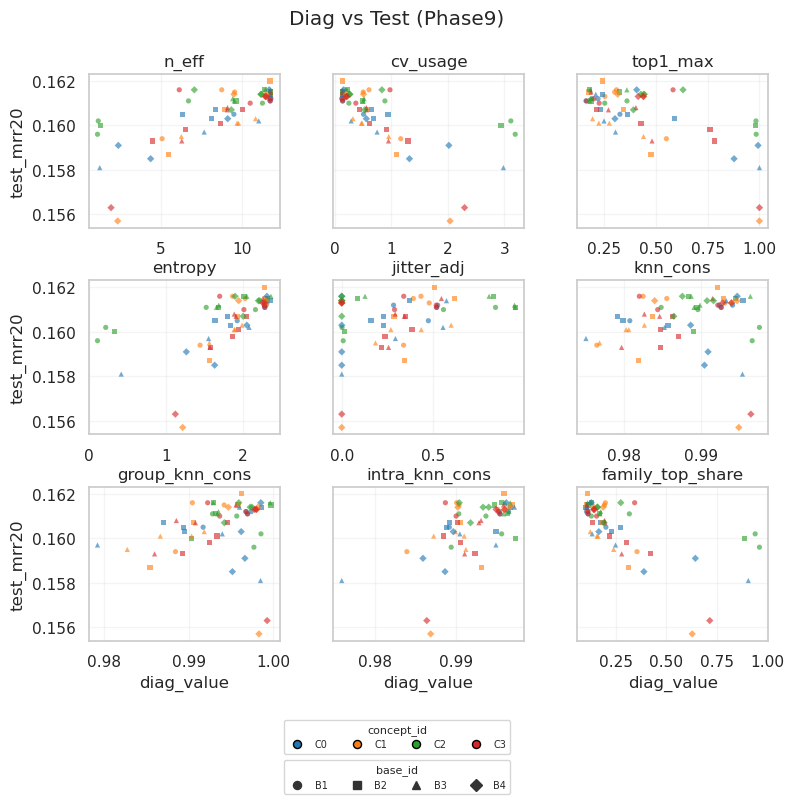

In [6]:
print('diag scatter(TEST): color=concept, marker=base')
_ = diag_facet_scatter(p9, 'test_mrr20', 'concept_id', 'base_id', 'Diag vs Test (Phase9)')
plt.show()


추가 diag 시각화 1: concept별 diag profile heatmap (z-score)


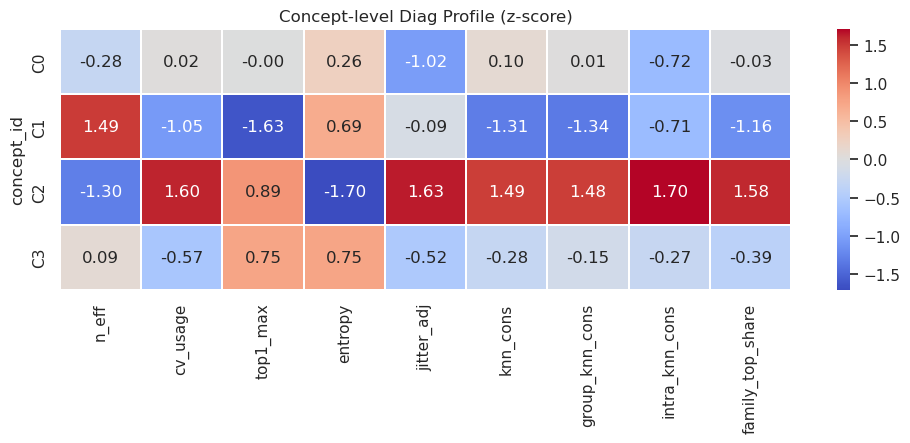

추가 diag 시각화 2: top25%-bottom25% valid 성능층 diag delta


/tmp/ipykernel_113741/2377265648.py:151: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=delta, x='diag_metric', y='delta', palette='coolwarm')


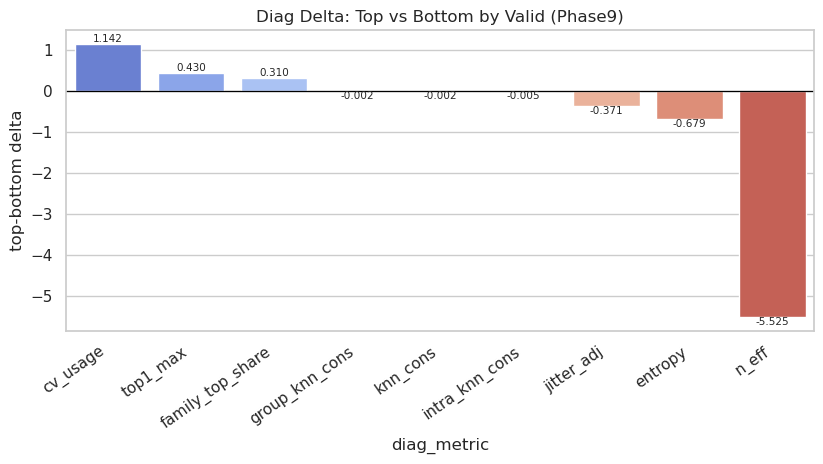

추가 diag 시각화 3: concept별 Spearman 상관 heatmap (diag vs valid)


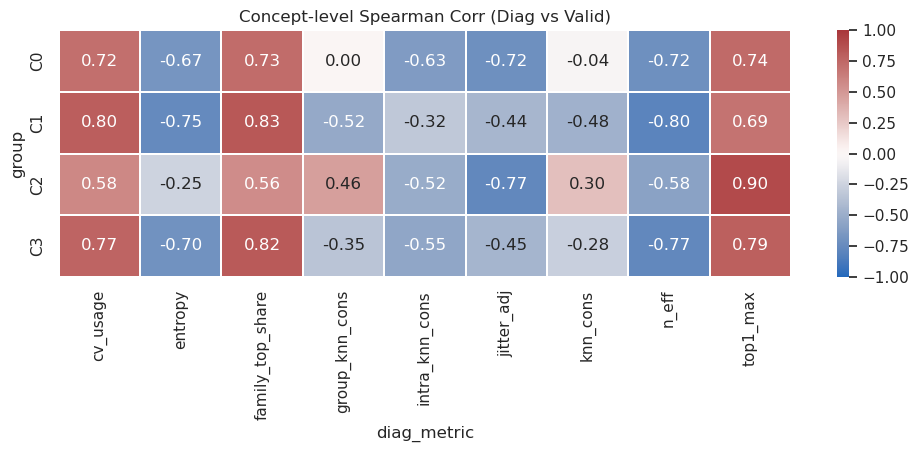

추가 diag 시각화 4: concept별 Spearman 상관 heatmap (diag vs test)


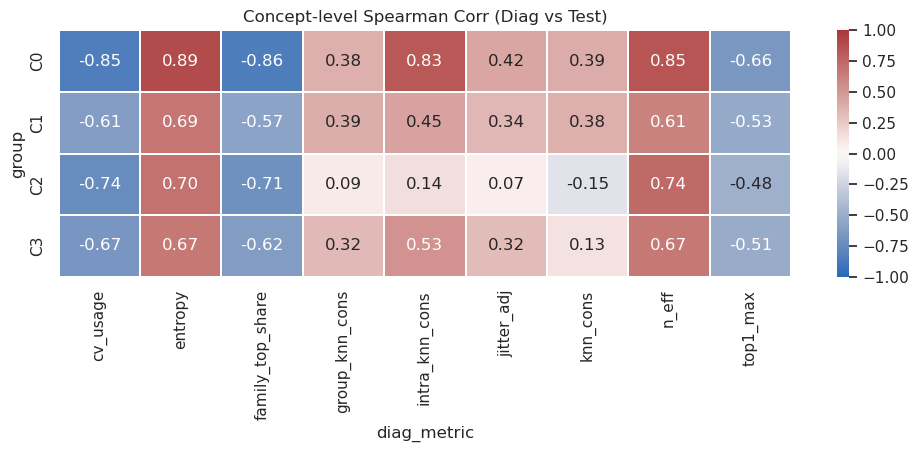

상관 요약(전체): diag vs valid/test 상위 연관 지표
     diag_metric  spearman   pearson
        top1_max  0.742822  0.670121
family_top_share  0.721841  0.560026
           n_eff -0.677009 -0.687811
        cv_usage  0.677009  0.590168
         entropy -0.561186 -0.530175
      jitter_adj -0.555377 -0.456515
     diag_metric  spearman   pearson
         entropy  0.710458  0.614152
           n_eff  0.701631  0.758499
        cv_usage -0.701631 -0.681954
family_top_share -0.657881 -0.650823
  intra_knn_cons  0.551453  0.607843
        top1_max -0.473917 -0.694306
추가 diag 시각화 5: diag 분위수(5분위)별 valid 평균 추세


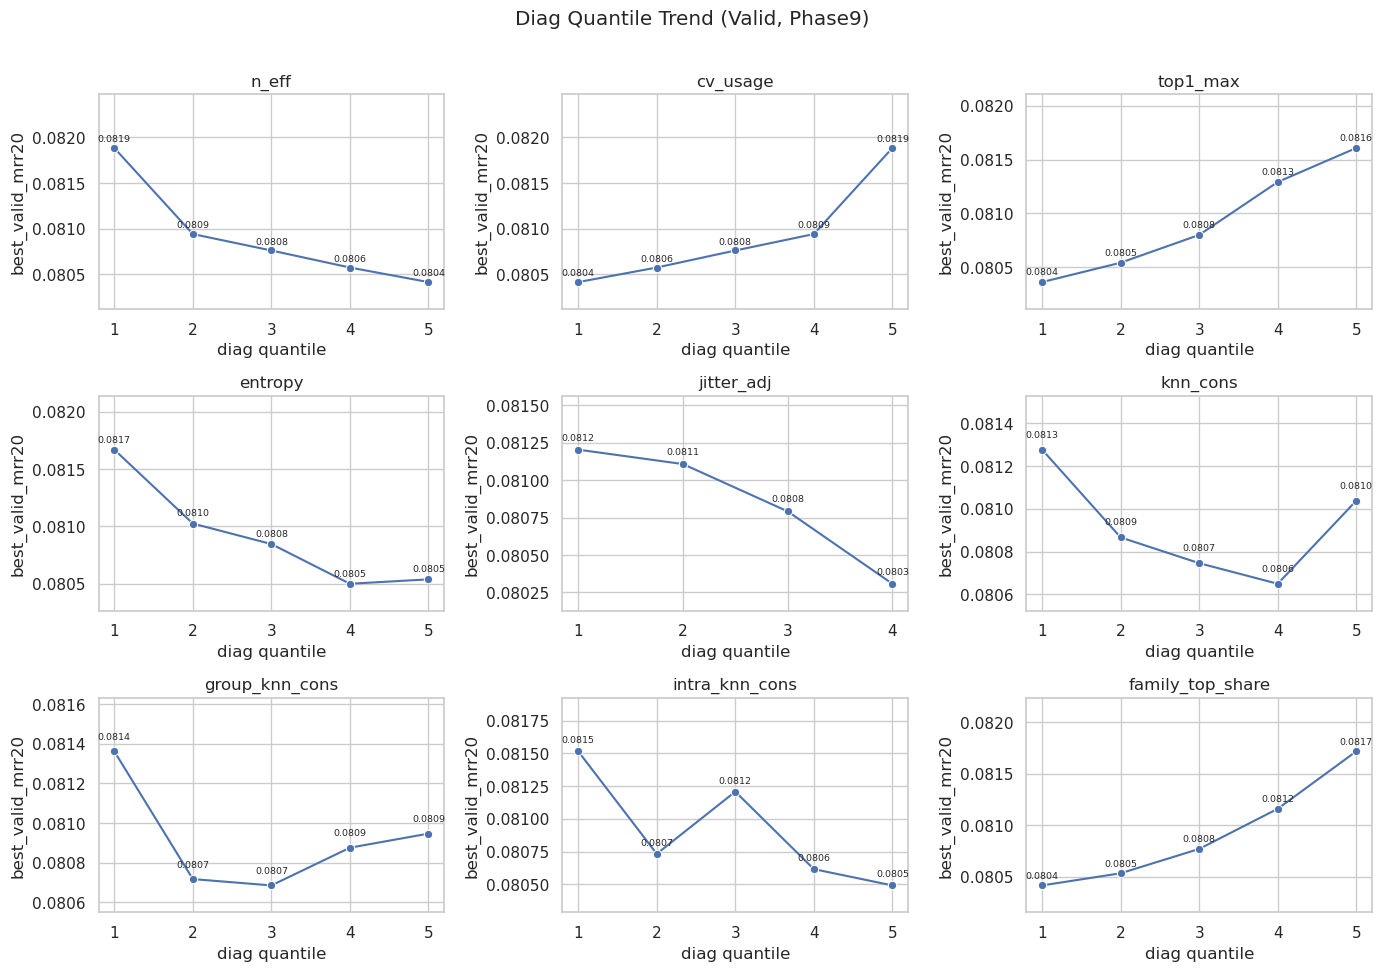

추가 diag 시각화 6: diag 분위수(5분위)별 test 평균 추세


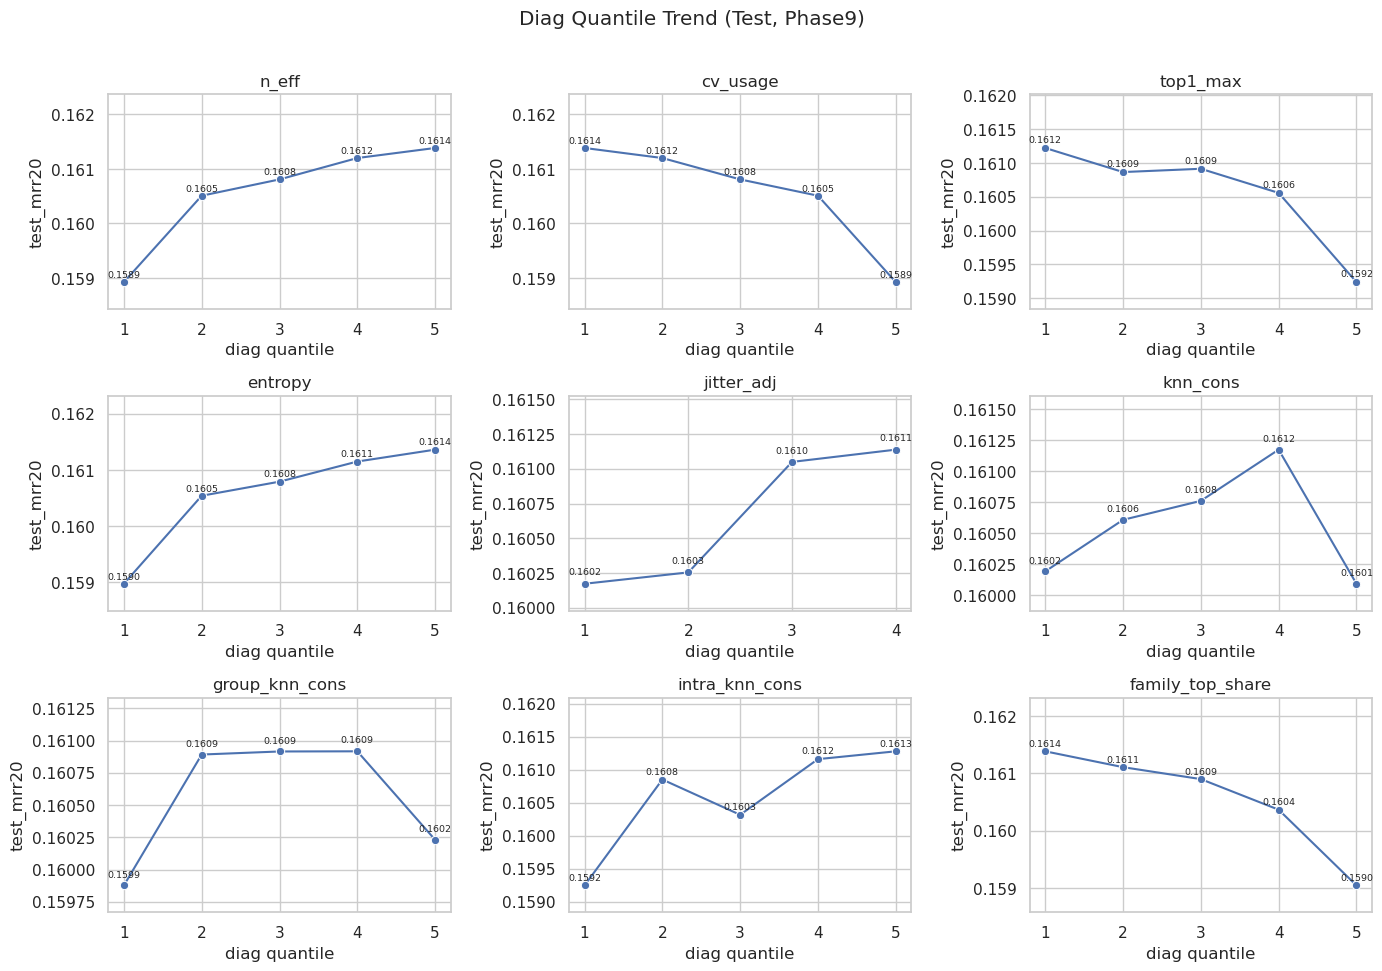

In [7]:
print('추가 diag 시각화 1: concept별 diag profile heatmap (z-score)')
group_diag_heatmap(p9, 'concept_id', 'Concept-level Diag Profile (z-score)')
plt.show()

print('추가 diag 시각화 2: top25%-bottom25% valid 성능층 diag delta')
top_bottom_diag_delta(p9, 'best_valid_mrr20', 'Diag Delta: Top vs Bottom by Valid (Phase9)')
plt.show()

print('추가 diag 시각화 3: concept별 Spearman 상관 heatmap (diag vs valid)')
diag_corr_heatmap(p9, 'concept_id', 'best_valid_mrr20', 'Concept-level Spearman Corr (Diag vs Valid)')
plt.show()

print('추가 diag 시각화 4: concept별 Spearman 상관 heatmap (diag vs test)')
diag_corr_heatmap(p9, 'concept_id', 'test_mrr20', 'Concept-level Spearman Corr (Diag vs Test)')
plt.show()

print('상관 요약(전체): diag vs valid/test 상위 연관 지표')
print(diag_corr_summary(p9, 'best_valid_mrr20').head(6).to_string(index=False))
print(diag_corr_summary(p9, 'test_mrr20').head(6).to_string(index=False))

print('추가 diag 시각화 5: diag 분위수(5분위)별 valid 평균 추세')
diag_quantile_profile(p9, 'best_valid_mrr20', 'Diag Quantile Trend (Valid, Phase9)')
plt.show()

print('추가 diag 시각화 6: diag 분위수(5분위)별 test 평균 추세')
diag_quantile_profile(p9, 'test_mrr20', 'Diag Quantile Trend (Test, Phase9)')
plt.show()


feature PCA 시각화(Phase9 + Phase9_2)


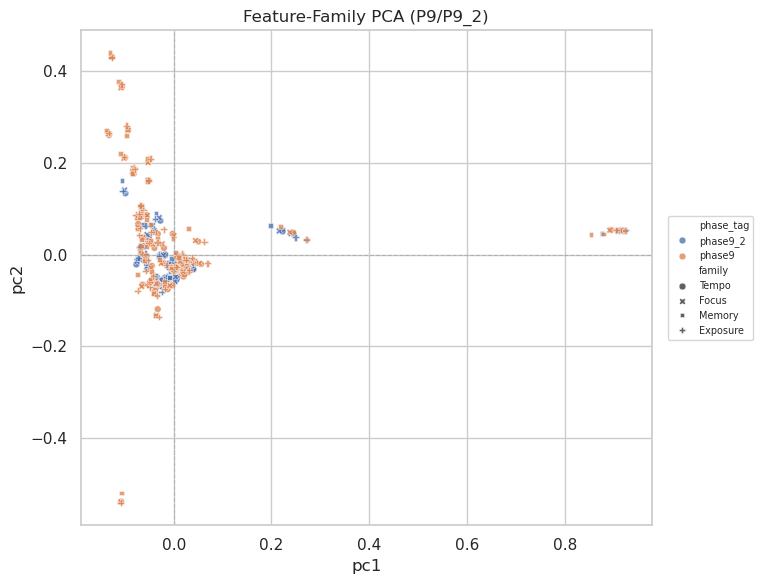

In [8]:
print('feature PCA 시각화(Phase9 + Phase9_2)')
pts = p9_pca[['run_phase','phase_tag','family','pc1','pc2','best_valid_mrr20','test_mrr20']].drop_duplicates()
fig, ax = pca_family_scatter(pts, 'Feature-Family PCA (P9/P9_2)', hue_col='phase_tag', style_col='family', categorical_hue=True)
plt.tight_layout()
plt.show()


Phase9_2는 진행률만 짧게 표시합니다.


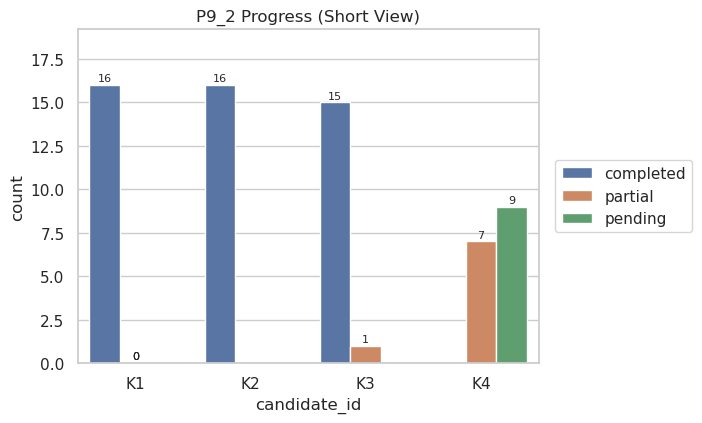

In [9]:
print('Phase9_2는 진행률만 짧게 표시합니다.')
all92 = pd.concat([p92, p92p], ignore_index=True)
prog = all92.groupby(['candidate_id','status']).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(7.2,4.4))
sns.barplot(data=prog, x='candidate_id', y='count', hue='status', ax=ax)
ax.set_title('P9_2 Progress (Short View)')
ax.set_ylim(0, max(1, prog['count'].max()) * 1.20)
for p in ax.patches:
    h = p.get_height()
    ax.text(p.get_x()+p.get_width()/2, h+0.1, f'{int(h)}', ha='center', va='bottom', fontsize=8)
ax.legend(loc='center left', bbox_to_anchor=(1.02,0.5), frameon=True)
plt.tight_layout()
plt.show()
